In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#import data
conn = sqlite3.connect('customer_churn.db')

sql_query = """
            SELECT name
            FROM sqlite_master
            WHERE type ='table'
"""

tables = pd.read_sql(sql_query,conn)

#create dataframe for each table
for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()


Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
#Print table name and column names
conn = sqlite3.connect('customer_churn.db')
for table_name in tables['name']:
    print(f"\n Table Name: {table_name}")
    #Get column information
    columns_query= f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())

conn.close



 Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

 Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

 Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


<function Connection.close()>

In [4]:
#Data Cleaning

In [5]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [6]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 2.5+ KB


In [7]:
#a. rename col-name
#b. drop col-interests,pincode
#c. change data type-dob
#d. data standardization-gender
#e. fix missing value-country

In [8]:
#a. rename col-name
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace=True)


In [9]:
#b. drop col-interests,pincode
#df_db_customer.drop(df_db_customer.columns[-2:],axis=1)
df_db_customer.drop(columns = {'interests', 'pincode'}, inplace=True)

In [10]:
#c. change data type-dob
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [11]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [12]:
#d. data standardization-gender
#df_db_customer['gender'].unique()
df_db_customer['gender']=df_db_customer['gender'].replace({'Men' : 'Male','Women' : 'Female'})

In [13]:
#e. fix missing value-country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [14]:
#country and state -unique value pair

state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [15]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [16]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [17]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [18]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 3.1 KB


In [19]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 2.7 KB


In [20]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [21]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 895.0+ bytes


In [22]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [23]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [24]:
#Feature Engineering and Data Analysis

In [25]:
#create a new col using exsisting col--churn_flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [26]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [27]:
df_db_support['customerid'].nunique()

7

In [28]:
df_db_support['customerid'].size

9

In [29]:
#counting of compalian
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [30]:
#drop the duplicates
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [31]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [32]:
# fitst fix the support table then Mergeing or joing of table in pandas
df= (df_db_subscription
                     .merge(df_db_customer, on ='customerid',how = 'left')
                     .merge(df_db_support, on ='customerid',how = 'left'))

In [33]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN


In [34]:
df.shape

(21, 21)

In [35]:
df.to_csv('exported_churn_data.csv',index=False)

In [36]:
#Data Analysis

In [37]:
#churn rate

In [38]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [39]:
churn_rate=df['churn_flag'].mean()*100
print("Churn Rate",round(churn_rate,2), "%")

Churn Rate 28.57 %


In [40]:
#Retention Rate
retention_rate= 100-churn_rate
print("Retention Rate",round(retention_rate,2), "%")

Retention Rate 71.43 %


In [41]:
#Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [42]:
#churn by state + sum(revenue) & count of users
#churn by subscription type
churn_by_state = (df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_state)

           state  churn_rate_pct
0          Delhi           25.00
1      Karnataka          100.00
2      Kathmandu            0.00
3    Maharashtra            0.00
4      Meghalaya           66.67
5       Nagaland            0.00
6      Rajasthan            0.00
7      Telangana           50.00
8  Uttar Pradesh            0.00


In [43]:
#ARPU --Avg revenue per user
arpu= df["monthly_charges"].mean()
print('Arpu = ' ,round(arpu,2))

Arpu =  18.85


In [44]:
#Avg Customer Tenure
#count of days user has used our service : cancellation_date else current_date

today=pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today-df['subscription_start_date']).dt.days

)

avg_tenure = df['tenure_days'].mean()
print('Avg Tenure (Days) = ',round(avg_tenure),0)
    


Avg Tenure (Days) =  1524 0


In [45]:
#Revenue at risk -revenue lost from churned users
revenue_at_risk= df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk  (Rs 'k') =",revenue_at_risk)

Revenue at Risk  (Rs 'k') = 73.94


In [46]:
#Escalation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate =",round(escalation_rate,2),"%")

Escalation Rate = 19.05 %


In [47]:
#Average complaint per user 
avg_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg Compliant per user =",round(avg_complaints,2))

Avg Compliant per user = 0.43


In [50]:
#Correlations escalation vs Churn
#df["escalations"] = np.where(df['escalations'] == 'Y',1,0)
corr_df = df [['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalation vs churn is ",round(correlation,2))

Correlation between escalation vs churn is  0.77


In [51]:
#Churn risk --create a column using existing col

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >=50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low','med','high']

df['churn_risk'] = np.select(conditions,choices,default='unknown')

In [52]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1988.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1373.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2663.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [55]:
#Visulaization with matplotlib

In [53]:
df_visual = df.copy()

In [54]:
df_visual

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1988.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1373.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2663.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,India,Delhi,Female,1988-12-10,2025-03-18,0,90.0,1.0,1528.0,low
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,India,Meghalaya,Female,1976-09-21,2024-11-01,0,30.0,1.0,1142.0,high
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,India,Rajasthan,Male,1999-03-14,NaT,0,NaN,NaN,2383.0,low
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,Nepal,Kathmandu,Female,1985-07-07,NaT,0,NaN,NaN,1129.0,low
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,Nepal,Kathmandu,Male,1993-10-29,NaT,0,NaN,NaN,1604.0,low


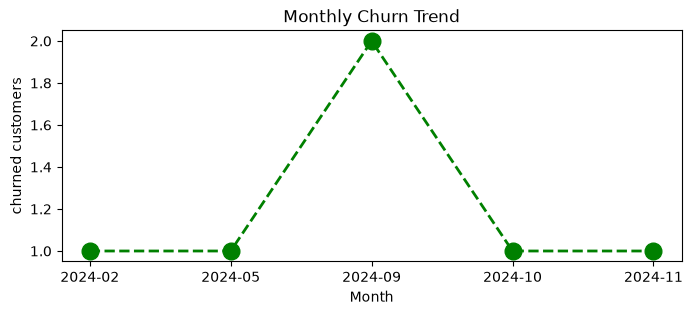

In [62]:
#Monthly Churn Trend(time series KPI)

df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values, color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('churned customers')
plt.show()

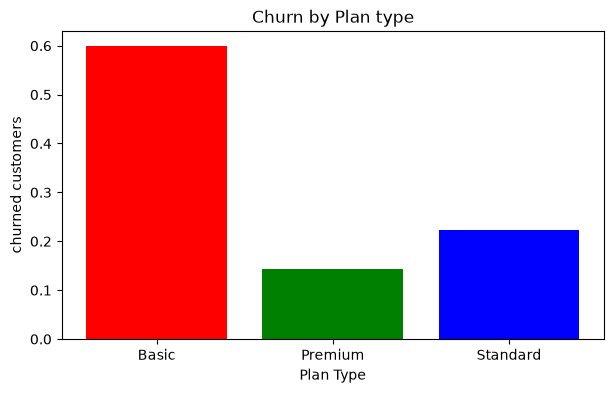

In [67]:
#Churn by Plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['red','green','blue']

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.title('Churn by Plan type')
plt.xlabel('Plan Type')
plt.ylabel('churned customers')
plt.show()


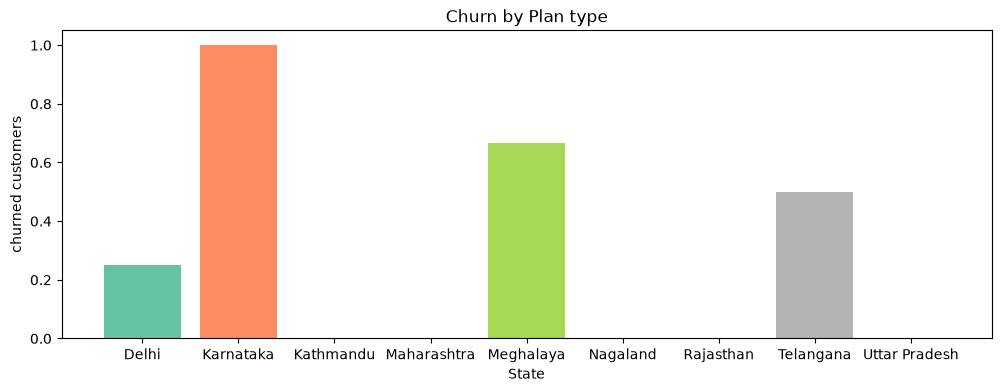

In [71]:
#Churn by state

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

#colors = ['red','green','blue']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.title('Churn by Plan type')
plt.xlabel('State')
plt.ylabel('churned customers')
plt.show()

In [72]:
#Visulaization with Seaborn

In [74]:
#incorrect method of encoding - as numbers are not assigned based on priority
df_encoded=df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

categorial_cols = ['plan_type','contract_type','churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [75]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

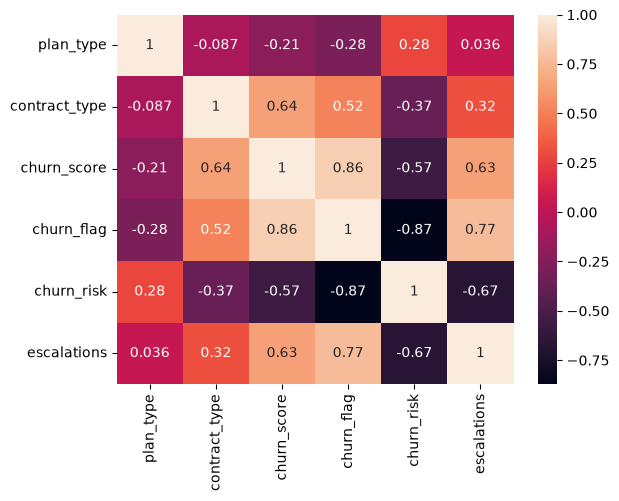

In [76]:
#Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(),annot=True)

In [77]:
#correct method of encoding based on priority
df_encoded=df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

order_mappings = {
    'plan_type': ['Basic','Standard','Premium'],
    'contract_type': ['Monthly','Annual'],
    'churn_risk': ['low','med','high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories=order, ordered=True).codes

<Axes: >

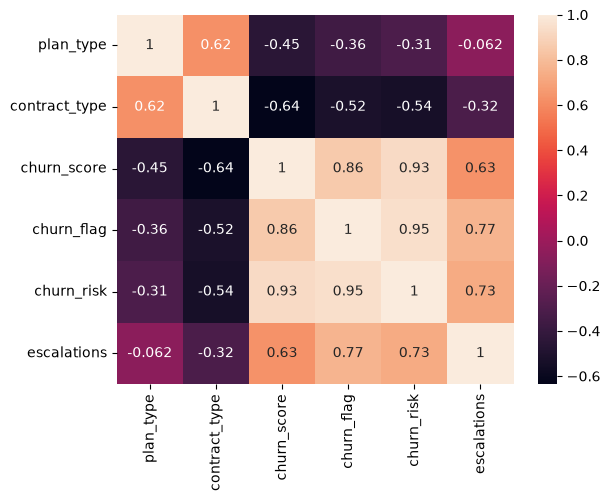

In [78]:
#Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(),annot=True)

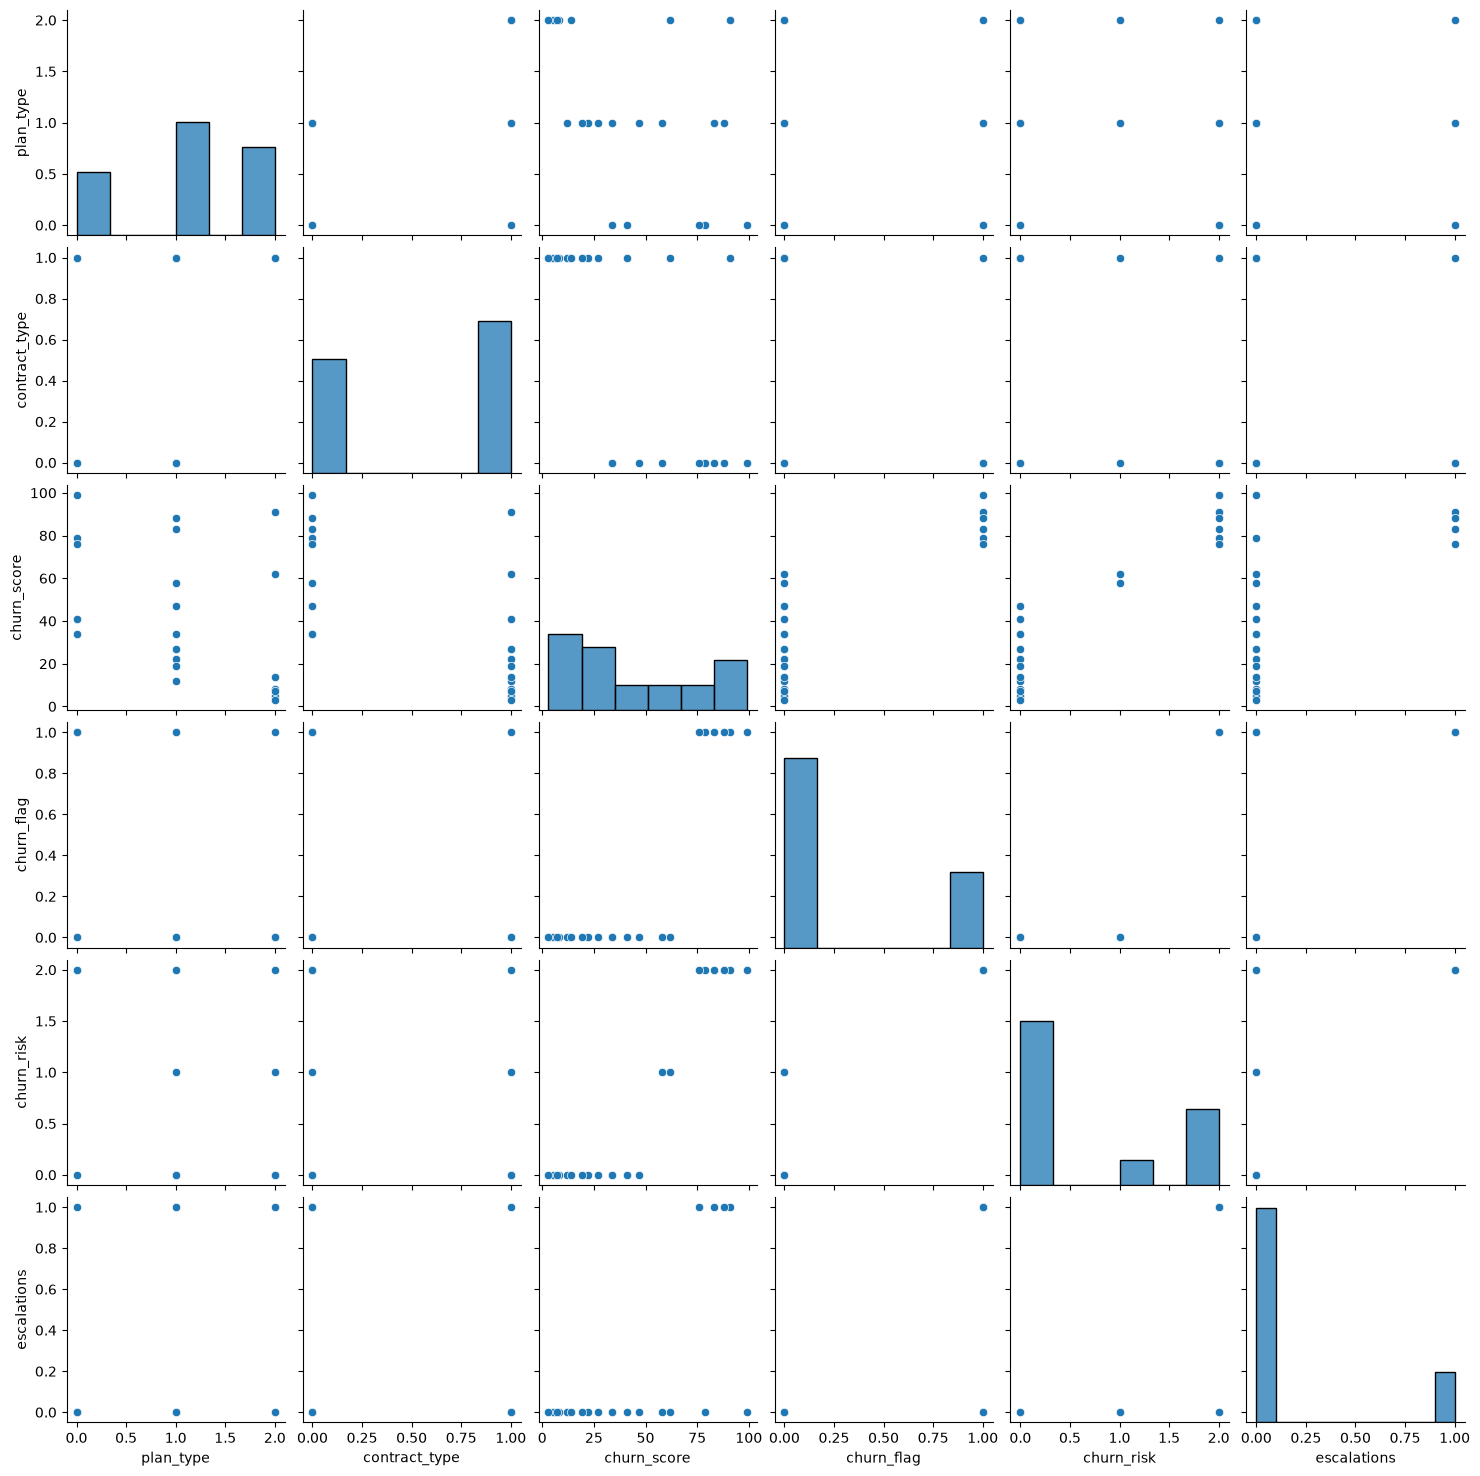

In [81]:
#pairplot--relationship in dataset
sns.pairplot(df_encoded)

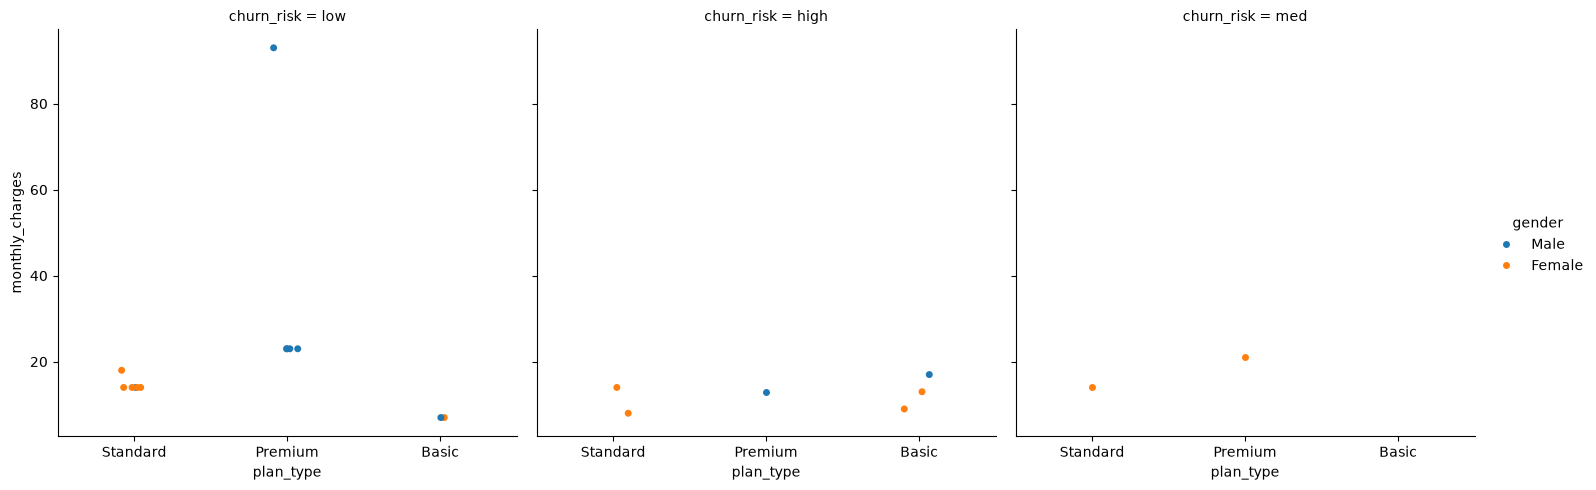

In [82]:
#catplt/Facegrid plot - multi-dim comparision

sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk'
           )

In [83]:
#pivot table

pd.pivot_table(
        df_visual,
        values='churn_flag',
        index='plan_type',
        aggfunc= 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [89]:
pd.pivot_table(
        df_visual,
        index='plan_type',
        values=['monthly_charges','customerid','churn_flag'],
        aggfunc= {
            'monthly_charges':'sum',
            'customerid':'nunique',
            'churn_flag':'mean'
        }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [88]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [91]:
#working with sql in python(pandas)

#create db in sql
conn = sqlite3.connect('test_database.sqllite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT,country TEXT,budget INTEGER)")

#commit and save
conn.commit()


In [95]:
#insert data

cursor = conn.cursor()

cursor.execute(
    """
        INSERT INTO users VALUES
            ('Madhav','INDIA',5000),
            ('RAM','GERMANY',2500),
            ('RISABH','INDIA',3500)
    
    """
)
#commit and save
conn.commit()

print("Data inserted sucessfully")

Data inserted sucessfully


In [96]:
#check inserted data in table
conn = sqlite3.connect('test_database.sqllite')
query = """ SELECT * FROM users """

df_results = pd.read_sql(query,conn)

df_results.head()



,first_name,country,budget
0,Madhav,INDIA,5000
1,RAM,GERMANY,2500
2,RISABH,INDIA,3500
3,Madhav,INDIA,5000
4,RAM,GERMANY,2500


In [99]:
#aggregation
query = """
        SELECT country,sum(budget) as total_budget
        FROM users
        GROUP BY country
        """
df_agg = pd.read_sql(query,conn)
df_agg

,country,total_budget
0,GERMANY,5000
1,INDIA,17000


In [100]:
conn.close()